In [39]:
%pip install -r ../requirements.txt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import copernicusmarine
from datetime import timedelta
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import xarray as xr


In [13]:
copernicusmarine.login(
    username = "sng",
    password = "Copernicus1!",
)

INFO - 2026-09-18T22:17:37Z - Credentials file stored in C:\Users\syng8\.copernicusmarine\.copernicusmarine-credentials.


True

Data Loading

In [40]:
import pandas as pd

# Show all columns without truncation
pd.set_option('display.max_columns', None)

# Show all rows without truncation (Caution: can make notebooks very laggy if millions of rows)
pd.set_option('display.max_rows', None)

# Show full text/content inside each cell without clipping
pd.set_option('display.max_colwidth', None)

hae_url = "https://raw.githubusercontent.com/Break-Through-Tech/Oregon-State-University-1A-forecasting-risk-of-harmful-algal-blooms-in-coastal-marine-ecosystems/main/data/raw/harmful_algae_events.csv"

HAE_data = pd.read_csv(hae_url)

HAE_data.head()

C:\Users\syng8\AppData\Local\Temp\ipykernel_6752\437425108.py:14: DtypeWarning: Columns (6: Submitter, 19: Original Grid Code, 48: Unexplained Toxicity, 62: Additional Algae Info) have mixed types. Specify dtype option on import or set low_memory=False.
  HAE_data = pd.read_csv(hae_url)


,Event ID,Event Name,Year,Country,Region,Status,Submitter,Created At,Updated At,Event Date,Start Date,End Date,Date Comments,Quarantine Start,Quarantine End,Additional Date Info,Latitude,Longitude,Location Description,Original Grid Code,Monitoring Grids,Additional Location Info,Monitoring Programme?,Programme Name,Occurred Before?,Occurred Before Details,Water Discoloration,High Phytoplankton,Seafood Toxin,Mass Mortality,Foam/Mucilage,Freshwater,Other Effect,Other Effect Details,Humans Affected,Natural Fish Affected,Aquaculture Fish Affected,Shellfish Affected,Birds Affected,Marine Mammals Affected,Plankton Affected,Benthic Life Affected,Seaweed Affected,Other Terrestrial Affected,Impact Comments,Terrestrial Comments,Toxin Detected?,Toxicity Range,Unexplained Toxicity,Toxicity Comments,Transvectors,Causative Species,Causative Species Details,Associated Species,Associated Species Details,Syndromes,Toxins Found,Assay Species Tested,Assay Toxins,Assay Concentrations,Assay Methods,Chlorophyll Analysis,Additional Algae Info,Weather Conditions,Wind Direction,Wind Velocity,Water Temp,Salinity,Oxygen Content,Oxygen Saturation,Turbidity,Secchi Disc,Current Velocity,Advected?,In Situ?,Advected Info,Stratification Info,Nutrients,Additional Env Info,Additional Harmful Effect Info,Additional Bloom Info,Management Decision,Economic Losses,References,Contacts
0,14822,NO-26-015,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,2026-05-04,2026-06-01,NaN,NaN,NaN,NaN,58.276080,5.547250,"Nordasundet, Egersund",NaN,NO-10,NaN,No,NaN,NaN,NaN,No,Yes,No,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,No,No,NaN,NaN,Alexandrium,Alexandrium [200 cells/L] (week 19 and 21),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was warned against picking toxic mussels.,Unknown,NaN,Mona Ring Kleiven
1,14819,NO-26-012,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,2026-04-20,2026-06-01,NaN,NaN,NaN,NaN,60.517717,4.890717,"Ulvsundet, Øygården",NaN,NO-10,NaN,No,NaN,NaN,NaN,No,No,Yes,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,1260-645 µg/kg,Yes,Week21,Mytulis edulis,NaN,NaN,NaN,NaN,PSP,NaN,Alexandrium,STX eq,1260 µg/kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was warned against picking toxic mussels.,Unknown,NaN,Mona Ring Kleiven
2,14810,NO-26-003,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-05-18,2026-05-18,NaN,2026-04-20,2026-05-04,NaN,NaN,NaN,Peak 23 th of April,58.424515,8.756882,"Flødevigen, Arendal, Agder.",NaN,NO-11,NaN,No,NaN,NaN,NaN,No,Yes,No,No,No,No,No,NaN,No,No,Yes,No,No,No,No,No,No,No,NaN,NaN,No,No,No,NaN,NaN,Chrysochromulina,Chrysochromulina [2378273 cells/L] (23.4.26),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0-3 m,NaN,NaN,NaN,NaN,NaN,Fish farms warned,NaN,NaN,Mona Ring Kleiven
3,14821,NO-26-014,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,2026-04-20,2026-06-15,NaN,NaN,NaN,NaN,62.503620,6.474960,"Mørkesetsundet, Ålesund",NaN,NO-08,NaN,No,NaN,NaN,NaN,No,No,Yes,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,PSP: 929-505 µg/kg/ AZP: 3267 µg/kg,Yes,NaN,Mytulis edulis,NaN,NaN,NaN,NaN,PSP; AZP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was warned against picking toxic mussels.,Unknown,NaN,Mona Ring Kleiven
4,14812,NO-26-005,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,2026-04-06,NaN,NaN,NaN,2026-04-20,2026-06-15,Alexandrium spp from week 15.,59.150000,10.690000,"Djupeklo, Fredrikstad",NaN,NO-14,NaN,No,NaN,NaN,NaN,No,Yes,Yes,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,945-696 µg/kg,No,NaN,Mytulis edu

In [41]:
list(ds.data_vars)

['thetao']

Addressing Missing Values & Outliers

In [42]:
df = pd.DataFrame(HAE_data)

# Missing Summary
missing_summary = pd.DataFrame({
    "missing_amt": df.isna().sum(),
    "missing_pct": df.isna().mean()
})
missing_summary

,missing_amt,missing_pct
Event ID,0,0.000000
Event Name,0,0.000000
Year,0,0.000000
Country,0,0.000000
Region,13856,0.982625
Status,0,0.000000
Submitter,14084,0.998794
Created At,3282,0.232749
Updated At,10913,0.773917
Event Date,6340,0.449614


In [ ]:
numeric_df = df.select_dtypes(include="number")

basic_statistics = numeric_df.agg(["mean", "std", "min", "max"]).T

basic_statistics


AttributeError: type object 'DataFrame' has no attribute 'dtype'

In [24]:
print("Duplicate rows:", df.duplicated().sum()) #There are no duplicates
df.describe(include = "all")

Duplicate rows: 0


,Event ID,Event Name,Year,Country,Region,Status,Submitter,Created At,Updated At,Event Date,...,Advected Info,Stratification Info,Nutrients,Additional Env Info,Additional Harmful Effect Info,Additional Bloom Info,Management Decision,Economic Losses,References,Contacts
count,14101.000000,14101,14101.000000,14101,245,14101,17,10819,3188,7761,...,835,1758.000000,0.0,596,1764,169,3949,815,2154,13801
unique,NaN,14101,NaN,106,15,2,3,1043,482,4650,...,335,NaN,NaN,455,1101,163,1337,545,1183,540
top,NaN,NO-26-015,NaN,FRENCH POLYNESIA,Region 12 (EUR),Approved,mona.ring.kleiven@hi.no,2018-09-27,2019-12-03,2020-11-27,...,Sampling aprox 0-3 meters,NaN,NaN,Sampling aprox 0-3 meters,http://www.intecmar.gal/Informacion/biotoxinas...,A slight halocline was observed,Harvesting was locally banned. The public was ...,Mussel plants were banned from harvesting.,More details in China Disaster Bulletin,"GATTI, Clémence"
freq,NaN,1,NaN,3968,63,14084,15,154,179,38,...,146,NaN,NaN,39,145,3,459,59,116,3964
mean,7628.603503,NaN,2008.732147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.118885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4245.972102,NaN,10.346621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.323745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,1770.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4132.000000,NaN,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7721.000000,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,11293.000000,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
pd.set_option('display.max_rows', 20)

HAE_data[
    HAE_data["Event Date"].isna()
][["Region", "Event Date", "Start Date", "End Date"]]

,Region,Event Date,Start Date,End Date
0,Region 12 (EUR),NaN,2026-05-04,2026-06-01
1,Region 12 (EUR),NaN,2026-04-20,2026-06-01
2,Region 12 (EUR),NaN,2026-04-20,2026-05-04
3,Region 12 (EUR),NaN,2026-04-20,2026-06-15
5,Region 12 (EUR),NaN,2026-04-06,2026-05-18
...,...,...,...,...
14091,NaN,NaN,1936-01-01,1936-01-31
14092,NaN,NaN,1916-11-01,1916-12-31
14093,NaN,NaN,1910-11-01,1911-01-31
14096,NaN,NaN,1901-01-01,1901-01-31


Dropped values that have empty dates or latitude/longitude as that is needed


In [50]:

HAE_clean = HAE_data.copy()

no_lat_lon_mask = (
    HAE_clean["Latitude"].isna() |
    HAE_clean["Longitude"].isna()
)

no_date_mask = (
    HAE_clean["Event Date"].isna() &
    HAE_clean["Start Date"].isna() &
    HAE_clean["End Date"].isna()
)

# Note that all of them at least still have the year, so we can still use them for some analyses if possible
print("Rows with no temporal information:", no_date_mask.sum())
print("Rows with no spatial information:", no_lat_lon_mask.sum())

HAE_clean = HAE_clean[~no_date_mask].copy()
HAE_clean = HAE_clean.dropna(subset=["Latitude", "Longitude"]).copy()

print("Original rows:", len(HAE_data))
print("Cleaned rows:", len(HAE_clean))

Rows with no temporal information: 3836
Rows with no spatial information: 57
Original rows: 14101
Cleaned rows: 10243


In [51]:
print("Latitude range:", HAE_clean["Latitude"].min(), "to", HAE_clean["Latitude"].max())
print("Longitude range:", HAE_clean["Longitude"].min(), "to", HAE_clean["Longitude"].max())
#Note: Strange longitude range, should only be -180 to 180

Latitude range: -78.383333 to 82.233333
Longitude range: -808.8684 to 177.288889


In [52]:
extreme_lon_rows = HAE_clean[HAE_clean["Longitude"] < -180]
print(extreme_lon_rows[["Latitude", "Longitude", "Country", "Region", "Event Date", "Start Date", "End Date"]])
#Noticed incorrect longitude, decimal should be shifted back

       Latitude  Longitude Country Region  Event Date  Start Date    End Date
961     21.7187  -808.8684  MEXICO    NaN  2022-08-18  2022-05-01  2022-09-04
4237    21.7187  -808.8684  MEXICO    NaN         NaN  2015-07-07  2015-07-30
4240    21.7187  -808.8684  MEXICO    NaN         NaN  2015-09-09  2015-09-29
6307    21.7187  -808.8684  MEXICO    NaN         NaN  2011-10-15  2011-10-18
6318    21.7187  -808.8684  MEXICO    NaN         NaN  2011-07-22  2011-12-16
8083    21.7187  -808.8684  MEXICO    NaN         NaN  2008-06-04  2008-06-05
8088    21.7187  -808.8684  MEXICO    NaN         NaN  2008-06-23  2008-07-10
10382   21.7187  -808.8684  MEXICO    NaN         NaN  2003-07-25  2003-08-10


In [53]:
mask = (HAE_clean["Longitude"] < -180) & (HAE_clean["Longitude"] > -900)

HAE_clean.loc[mask, "Longitude"] = HAE_clean.loc[mask, "Longitude"] / 10
print(HAE_clean[HAE_clean["Latitude"] == 21.7187][["Latitude", "Longitude", "Country"]])

       Latitude  Longitude Country
961     21.7187  -80.88684  MEXICO
4237    21.7187  -80.88684  MEXICO
4240    21.7187  -80.88684  MEXICO
6307    21.7187  -80.88684  MEXICO
6318    21.7187  -80.88684  MEXICO
8083    21.7187  -80.88684  MEXICO
8088    21.7187  -80.88684  MEXICO
10382   21.7187  -80.88684  MEXICO


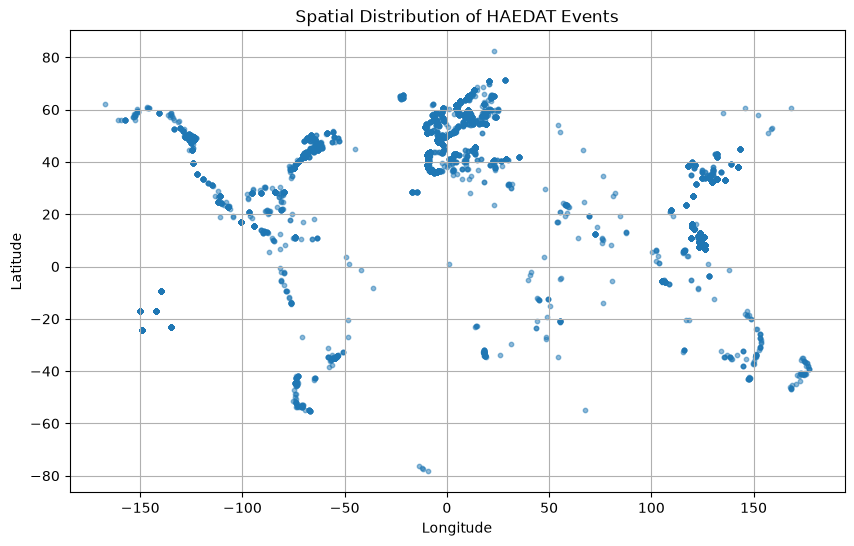

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(HAE_clean["Longitude"], HAE_clean["Latitude"], alpha=0.5, s=10)
plt.title("Spatial Distribution of HAEDAT Events")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

**Statistics (Mayowa)**

In [31]:
#STATS
import numpy as np
import pandas as pd
import xarray as xr
import copernicusmarine
import matplotlib.pyplot as plt

In [32]:
# Copernicus global ocean physics reanalysis
PHYSICS_DATASET_ID = "cmems_mod_glo_phy_my_0.083deg_P1D-m"

# Start with temperature and salinity
PHYSICS_VARIABLES = [
    "thetao",  # Sea water temperature
    "so"       # Sea water salinity
]

# Use a 1-degree box around each event location
BUFFER_DEGREES = 1.0

# Copernicus data are daily, so allow a difference of up to one day
MAX_TIME_DIFFERENCE = pd.Timedelta(days=1)

In [33]:
physics_ds = copernicusmarine.open_dataset(
    dataset_id=PHYSICS_DATASET_ID,
    variables=PHYSICS_VARIABLES
)

physics_ds

INFO - 2026-09-18T22:18:33Z - Selected dataset version: "202311"
INFO - 2026-09-18T22:18:33Z - Selected dataset part: "default"


<xarray.Dataset> Size: 86TB
Dimensions:    (depth: 50, latitude: 2041, longitude: 4320, time: 12227)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * time       (time) datetime64[ns] 98kB 1993-01-01 1993-01-02 ... 2026-06-23
Data variables:
    thetao     (time, depth, latitude, longitude) float64 43TB dask.array<chunksize=(50, 2, 512, 2048), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float64 43TB dask.array<chunksize=(50, 2, 512, 2048), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1